In [1]:
import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "7"
import numpy as np

In [11]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.11.0


In [3]:
! pip install scikit-learn

  Using cached scikit_learn-1.5.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.5.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.4 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)


In [46]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc')
cfs = dataset.variables['pr'][:]
lat = dataset.variables['latitude'][:]
lon = dataset.variables['longitude'][:]

# Repeat z=1 for 52 times
cfs_repeated = np.repeat(cfs, 52, axis=1)

# Identify the indices for the specified latitude and longitude bounds
lat_indices = np.where(lat > 6)[0][:32]
lon_indices = np.where(lon > 68)[0][:32]

# Crop the data based on these indices
cfs_cropped = cfs_repeated[:, :, lat_indices.min():lat_indices.max()+1, lon_indices.min():lon_indices.max()+1]

# Generate samples
samples = []
for t in range(cfs_cropped.shape[0]):  # Iterate over the time dimension (30)
    for start_z in range(43):  # 0 to 42 (for a window of 10, last start_z is 42)
        sample = cfs_cropped[t, start_z:start_z+10, :, :]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 32, 32, 1)
samples = samples[..., np.newaxis]

# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
y_train, y_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {y_train.shape}")
print(f"Testing data shape: {y_test.shape}")


Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [1]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc')
cfs = dataset.variables['pr'][:]
lat = dataset.variables['latitude'][:]
lon = dataset.variables['longitude'][:]

# Repeat z=1 for 52 times
cfs_repeated = np.repeat(cfs, 52, axis=1)

# Identify the indices for the specified latitude and longitude bounds
lat_indices = np.where(lat > 6)[0][:32]
lon_indices = np.where(lon > 68)[0][:32]

# Crop the data based on these indices
cfs_cropped = cfs_repeated[:, :, lat_indices.min():lat_indices.max()+1, lon_indices.min():lon_indices.max()+1]

# Generate samples
samples = []
for t in range(cfs_cropped.shape[0]):  # Iterate over the time dimension (30)
    for z in range(43):  # Iterate over the z dimension (depth or z frames)
        sample = cfs_cropped[t, z:z+10, :, :]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 32, 32, 1)
samples = samples[..., np.newaxis]

path='/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/'
np.save(path+'pr_rainfall_26_06',samples)

# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
y_train, y_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {y_train.shape}")
print(f"Testing data shape: {y_test.shape}")


/home/hpcs_rnd/anaconda3/envs/Yatendra_Env/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [2]:
np.save(path+'y_rainfall_26_06',y_train)
np.save(path+'yt_rainfall_26_06',y_test)

In [4]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc')
cfs = dataset.variables['cfs'][:]

# Generate samples
samples = []
for t in range(cfs.shape[0]):  # Iterate over the time dimension (30)
    for start_z in range(43):  # 0 to 42 (for a window of 10, last start_z is 42)
        sample = cfs[t, start_z:start_z+10, :32, :32]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 33, 35, 1)
samples = samples[..., np.newaxis]

path='/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/'
np.save(path+'cfs_rainfall_26-06',samples)
# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
X_train, X_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")




Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [3]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc')
cfs = dataset.variables['cfs'][:]

# Generate samples
samples = []
for t in range(cfs.shape[0]):  # Iterate over the time dimension (30)
    for z in range(43):  # Iterate over the z dimension (depth or z frames)
        sample = cfs[t, z:z+10, :32, :32]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 32, 32, 1)
samples = samples[..., np.newaxis]

# Save samples to numpy file
# path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/'
# np.save(path + 'cfs_rainfall_26-06.npy', samples)

# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
X_train, X_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

path='/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/'
np.save(path+'X_train_24_06.npy',X_train)
np.save(path+'Xt_test_24_06.npy',X_test)

Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [48]:
import numpy as np
cfs_original_cropped=np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_train_24_06.npy')
cfs_repeated_cropped=np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_train_24_06.npy')
avg_original = np.mean(cfs_original_cropped, axis=1)
avg_repeated = np.mean(cfs_repeated_cropped, axis=1)

# Check the shapes of the averages
print(f"Grid-wise average shape for original dataset: {avg_original.shape}")
print(f"Grid-wise average shape for repeated dataset: {avg_repeated.shape}")

# Flatten the grid-wise averages for correlation calculation
flattened_avg_original = avg_original.flatten()
flattened_avg_repeated = avg_repeated.flatten()

# Calculate the correlation
correlation = np.corrcoef(flattened_avg_original, flattened_avg_repeated)[0, 1]

Grid-wise average shape for original dataset: (1032, 32, 32, 1)
Grid-wise average shape for repeated dataset: (1032, 32, 32, 1)


In [49]:
print(f"Correlation between the grid-wise averages of the original and repeated datasets: {correlation}")

Correlation between the grid-wise averages of the original and repeated datasets: 0.15121909149264207


In [9]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset with z=1
dataset_z1 = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc')
cfs_z1 = dataset_z1.variables['pr'][:]
lat = dataset_z1.variables['latitude'][:]
lon = dataset_z1.variables['longitude'][:]

# Identify the indices for the specified latitude and longitude bounds
lat_indices = np.where((lat > 6) & (lat < 86))[0]
lon_indices = np.where((lon > 66) & (lon < 146))[0]

# Crop the data based on these indices
cropped_cfs = cfs_z1[:, :, lat_indices.min():lat_indices.max()+1, lon_indices.min():lon_indices.max()+1]

# Check the shape of cropped_cfs
print(f"Cropped cfs shape: {cropped_cfs.shape}")

# Repeat the single z slice to create a new z dimension of size 10
repeated_cfs = np.repeat(cropped_cfs, 10, axis=1)  # Repeat along the z dimension

# Verify the new shape
print(f"New cfs shape after repeating: {repeated_cfs.shape}")

# Reshape to match input shape (num_samples, 10, cropped_lat_size, cropped_lon_size, 1)
repeated_cfs = repeated_cfs[..., np.newaxis]

# Calculate number of time samples
num_time_samples = repeated_cfs.shape[0]

# We treat each time slice independently since we can't create overlapping windows in z
# Hence, each time step will be a separate sample
samples = []
for t in range(num_time_samples):  # Iterate over the time dimension
    samples.append(repeated_cfs[t])

samples = np.array(samples)

# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset into training and testing sets
y_train, y_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {y_train.shape}")
print(f"Testing data shape: {y_test.shape}")


Cropped cfs shape: (30, 1, 32, 32)
New cfs shape after repeating: (30, 10, 32, 32)
Samples shape: (30, 10, 32, 32, 1)


ValueError: test_size=258 should be either positive and smaller than the number of samples 30 or a float in the (0, 1) range

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 1, 32, 32, 1 0                                            
__________________________________________________________________________________________________
conv3d_21 (Conv3D)              (None, 1, 32, 32, 64 46720       input_4[0][0]                    
__________________________________________________________________________________________________
dropout_12 (Dropout)            (None, 1, 32, 32, 64 0           conv3d_21[0][0]                  
__________________________________________________________________________________________________
conv3d_22 (Conv3D)              (None, 1, 32, 32, 32 55328       dropout_12[0][0]                 
____________________________________________________________________________________________

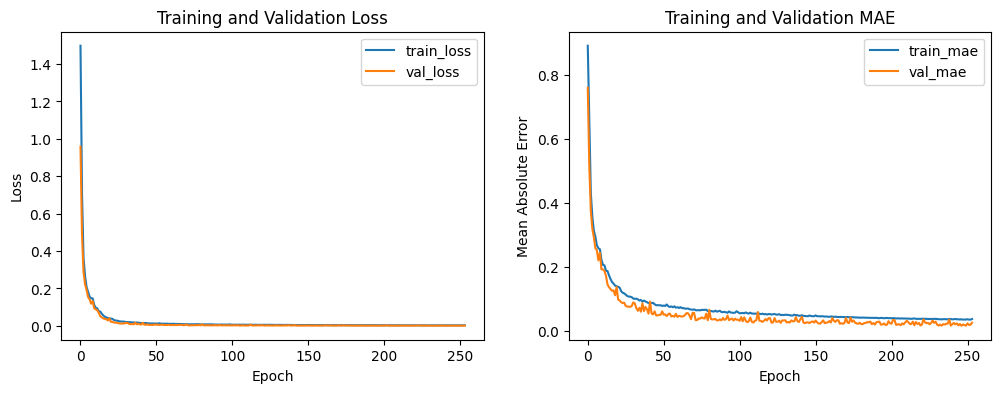

In [19]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc
import matplotlib.pyplot as plt


train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 

def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)

    # Crop or resize label data to match input spatial dimensions
    label = label[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)

def create_model():
  input_layer = layers.Input(shape=(1,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=20,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkmodel.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop
for i in range(1):
  trainx=[]
  trainy=[]
 # trainb=[]
  testx=[]
  testy=[]
  #testb=[]
  for j in range(0,24):
    tr_year=train_year[j]
    start_index_tr=(tr_year)*43
    end_index_tr=(tr_year+1)*43
    for l in range (start_index_tr,end_index_tr):
      trainx.append(data[l])
      trainy.append(label[l])
   #   trainb.append(biasdata[l])
  for k in range(0,6):
    ts_year=test_year[k]
    start_index_ts=(ts_year)*43
    end_index_ts=(ts_year+1)*43
    for m in range (start_index_ts,end_index_ts):
      testx.append(data[m])
      testy.append(label[m])
    #  testb.append(biasdata[m])
  tx=tf.convert_to_tensor(trainx)
  ty=tf.convert_to_tensor(trainy)
  tsx=tf.convert_to_tensor(testx)
  path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
  model_CNNBC,checkpoint,earlystop = create_model()
  history=model_CNNBC.fit(tx,ty,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
  model_CNNBC.save(path+"my_cnntrymodel.h5", include_optimizer=True)

  tr_result=model_CNNBC.predict(tx)
  ts_result=model_CNNBC.predict(tsx)

  rtrain=np.reshape(tr_result,(1032,32, 32))
  ## rtest : result of test data
  rtest=np.reshape(ts_result,(258, 32, 32))
  #ltrain = level data 
  ltrain=np.reshape(trainy,(1032, 32, 32))
  #ltest : level data for test 
  ltest=np.reshape(testy,(258, 32, 32))
  
  #btrain=np.reshape(trainb,(1032, 32, 32))
  #btest=np.reshape(testb,(258, 32, 32))

  # np.save(path+"/Result/tr_result"+str(i)+".npy",rtrain)
  # np.save(path+"/Result/ts_result"+str(i)+".npy",rtest)
  # np.save(path+"/Result/tr_label"+str(i)+".npy",ltrain)
  # np.save(path+"/Result/ts_label"+str(i)+".npy",ltest)
  # #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
  # #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)
  
  # del model_CNNBC,checkpoint,earlystop
  # del tr_result,ts_result
  # del tx,ty,tsx
  # del trainx,trainy,trainb,testx,testy,testb
  # del tr_year,ts_year
  # del start_index_tr,end_index_tr,start_index_ts,end_index_ts
  # del rtrain,rtest,ltrain,ltest,btrain,btest
  gc.collect()

def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)


In [23]:
tm=tf.convert_to_tensor(trainy)
tz=tf.convert_to_tensor(testy)
tm=tm.numpy()
tz=tz.numpy()
tr_result_flat = tr_result.flatten()
label_flat = tm.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tz.flatten()

# Calculate correlation coefficients
train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]



0.9998828508024936 0.9997940719602156


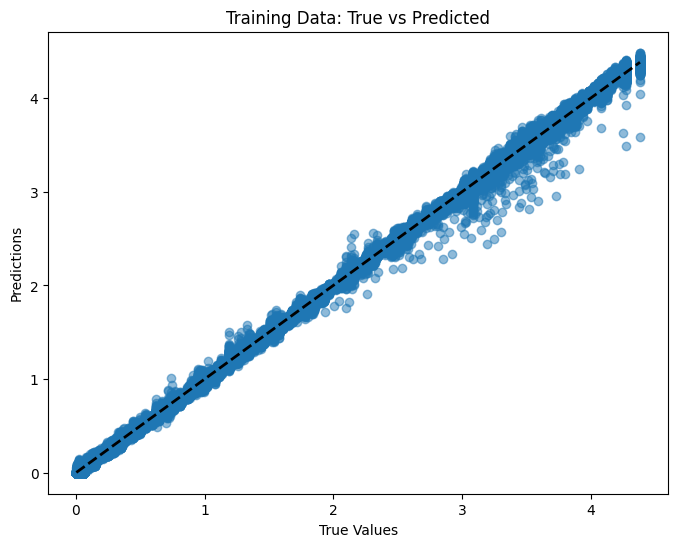

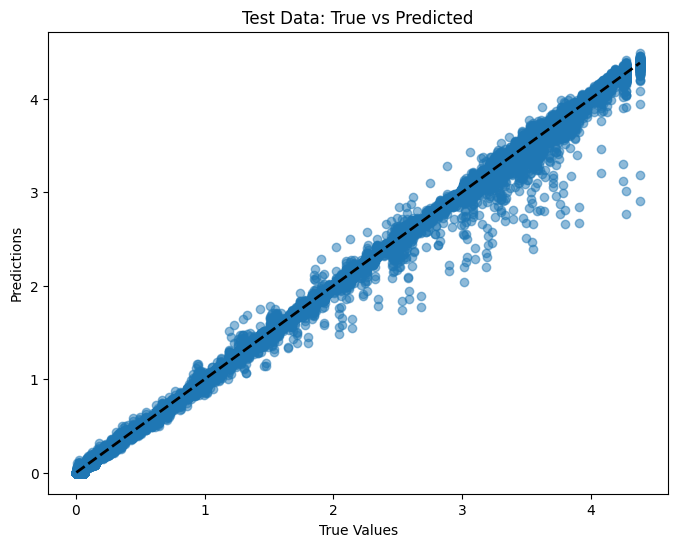

In [25]:
print(train_correlation,test_correlation)
def plot_predictions(true_values, predictions, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.show()

plot_predictions(label_flat, tr_result_flat, 'Training Data: True vs Predicted')
plot_predictions(tsx_flat, ts_result_flat, 'Test Data: True vs Predicted')

2024-06-26 16:45:16.388284: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
/home/hpcs_rnd/anaconda3/envs/Yatendra_Env/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2024-06-26 16:45:17.761494: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2024-06-26 16:45:18.013226: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:07:00.0 name: NVIDIA A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2024-06-26 16:45:18.016907: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:0b:00.0 name:

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 1, 32, 32, 1 0                                            
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, 1, 32, 32, 64 46720       input_1[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 1, 32, 32, 64 0           conv3d[0][0]                     
__________________________________________________________________________________________________
conv3d_1 (Conv3D)               (None, 1, 32, 32, 32 55328       dropout[0][0]                    
______________________________________________________________________________________________

2024-06-26 16:45:27.464387: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2024-06-26 16:45:27.465017: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2794960000 Hz


Epoch 1/500


2024-06-26 16:45:27.967340: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2024-06-26 16:45:28.996938: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8204
2024-06-26 16:45:30.408033: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2024-06-26 16:45:31.236679: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


52/52 - 5s - loss: 2.7577 - mean_absolute_error: 1.2927 - val_loss: 2.1972 - val_mean_absolute_error: 1.2389

Epoch 00001: val_loss improved from inf to 2.19722, saving model to checkmodel1.keras
Epoch 2/500
52/52 - 0s - loss: 2.0038 - mean_absolute_error: 1.2316 - val_loss: 1.9025 - val_mean_absolute_error: 1.2374

Epoch 00002: val_loss improved from 2.19722 to 1.90248, saving model to checkmodel1.keras
Epoch 3/500
52/52 - 0s - loss: 1.8903 - mean_absolute_error: 1.2292 - val_loss: 1.8995 - val_mean_absolute_error: 1.2041

Epoch 00003: val_loss improved from 1.90248 to 1.89950, saving model to checkmodel1.keras
Epoch 4/500
52/52 - 0s - loss: 1.8792 - mean_absolute_error: 1.2277 - val_loss: 1.8700 - val_mean_absolute_error: 1.2296

Epoch 00004: val_loss improved from 1.89950 to 1.86997, saving model to checkmodel1.keras
Epoch 5/500
52/52 - 0s - loss: 1.8715 - mean_absolute_error: 1.2276 - val_loss: 1.8651 - val_mean_absolute_error: 1.2310

Epoch 00005: val_loss improved from 1.86997 to

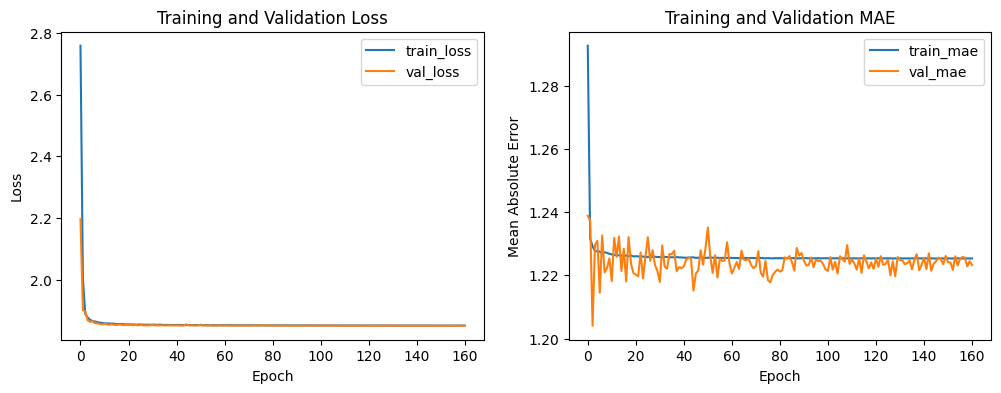

In [1]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc
import matplotlib.pyplot as plt


train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 

def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)

    # Crop or resize label data to match input spatial dimensions
    label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)

def create_model():
  input_layer = layers.Input(shape=(1,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=20,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkmodel1.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop
for i in range(1):
  trainx=[]
  trainy=[]
 # trainb=[]
  testx=[]
  testy=[]
  #testb=[]
  for j in range(0,24):
    tr_year=train_year[j]
    start_index_tr=(tr_year)*43
    end_index_tr=(tr_year+1)*43
    for l in range (start_index_tr,end_index_tr):
      trainx.append(data[l])
      trainy.append(label[l])
   #   trainb.append(biasdata[l])
  for k in range(0,6):
    ts_year=test_year[k]
    start_index_ts=(ts_year)*43
    end_index_ts=(ts_year+1)*43
    for m in range (start_index_ts,end_index_ts):
      testx.append(data[m])
      testy.append(label[m])
    #  testb.append(biasdata[m])
  tx=tf.convert_to_tensor(trainx)
  ty=tf.convert_to_tensor(trainy)
  tsx=tf.convert_to_tensor(testx)
  path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
  model_CNNBC,checkpoint,earlystop = create_model()
  history=model_CNNBC.fit(tx,ty,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
  model_CNNBC.save(path+"my_cnntry1model.h5", include_optimizer=True)

  tr_result=model_CNNBC.predict(tx)
  ts_result=model_CNNBC.predict(tsx)

  rtrain=np.reshape(tr_result,(1032,32, 32))
  ## rtest : result of test data
  rtest=np.reshape(ts_result,(258, 32, 32))
  #ltrain = level data 
  ltrain=np.reshape(trainy,(1032, 32, 32))
  #ltest : level data for test 
  ltest=np.reshape(testy,(258, 32, 32))
  
  #btrain=np.reshape(trainb,(1032, 32, 32))
  #btest=np.reshape(testb,(258, 32, 32))

  # np.save(path+"/Result/tr_result"+str(i)+".npy",rtrain)
  # np.save(path+"/Result/ts_result"+str(i)+".npy",rtest)
  # np.save(path+"/Result/tr_label"+str(i)+".npy",ltrain)
  # np.save(path+"/Result/ts_label"+str(i)+".npy",ltest)
  # #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
  # #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)
  
  # del model_CNNBC,checkpoint,earlystop
  # del tr_result,ts_result
  # del tx,ty,tsx
  # del trainx,trainy,trainb,testx,testy,testb
  # del tr_year,ts_year
  # del start_index_tr,end_index_tr,start_index_ts,end_index_ts
  # del rtrain,rtest,ltrain,ltest,btrain,btest
  gc.collect()

def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)


In [2]:
tm=tf.convert_to_tensor(trainy)
tz=tf.convert_to_tensor(testy)
tm=tm.numpy()
tz=tz.numpy()
tr_result_flat = tr_result.flatten()
label_flat = tm.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tz.flatten()

# Calculate correlation coefficients
train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]
print(train_correlation,test_correlation)


0.8692485229244082 0.8700236984332403


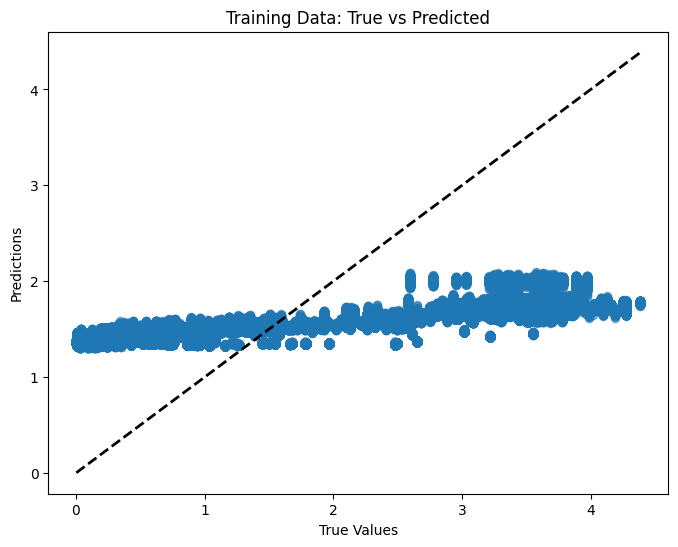

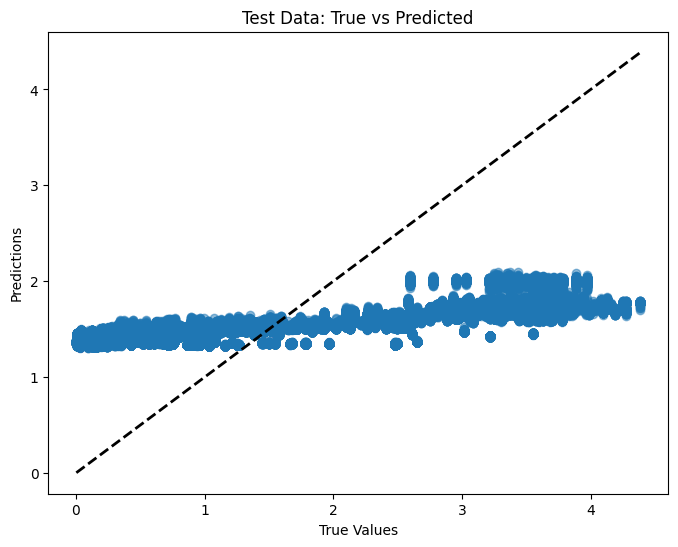

In [3]:
print(train_correlation,test_correlation)
def plot_predictions(true_values, predictions, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.show()

plot_predictions(label_flat, tr_result_flat, 'Training Data: True vs Predicted')
plot_predictions(tsx_flat, ts_result_flat, 'Test Data: True vs Predicted')

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d_21 (Conv3D)              (None, 10, 32, 32, 6 46720       input_4[0][0]                    
__________________________________________________________________________________________________
dropout_12 (Dropout)            (None, 10, 32, 32, 6 0           conv3d_21[0][0]                  
__________________________________________________________________________________________________
conv3d_22 (Conv3D)              (None, 10, 32, 32, 3 55328       dropout_12[0][0]                 
____________________________________________________________________________________________

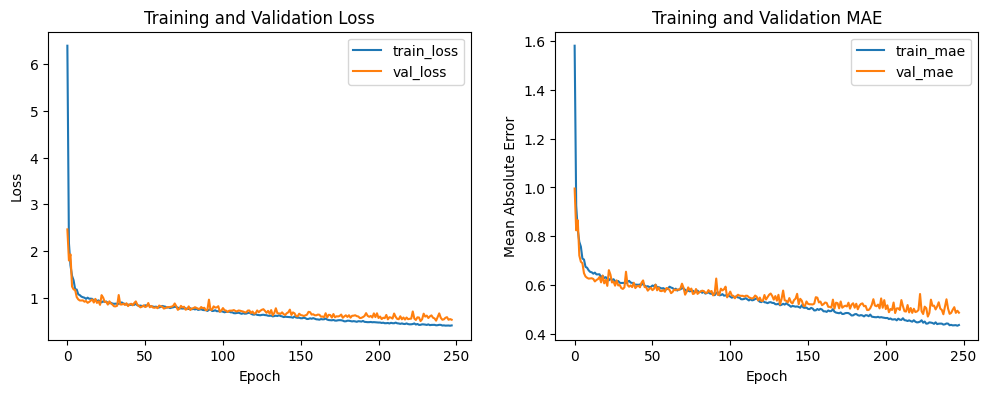

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1056768 and the array at index 1 has size 10567680

In [10]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc
import matplotlib.pyplot as plt

import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "7"

train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/X_train_24_06.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/y_rainfall_26_06.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 
tsx=np.load('/home/hpcs_rnd/X_test_24_06.npy')
tsy=np.load('/home/hpcs_rnd/yt_rainfall_26_06.npy')

# def preprocess_data(label):
#     # Crop or resize label data to match input spatial dimensions
#     label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

#     return label

# # Preprocess data
# label = preprocess_data( label)

def create_model():
  input_layer = layers.Input(shape=(10,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=20,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkmodel1.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop
# for i in range(1):
#   trainx=[]
#   trainy=[]
#  # trainb=[]
#   testx=[]
#   testy=[]
#   #testb=[]
#   for j in range(0,24):
#     tr_year=train_year[j]
#     start_index_tr=(tr_year)*43
#     end_index_tr=(tr_year+1)*43
#     for l in range (start_index_tr,end_index_tr):
#       trainx.append(data[l])
#       trainy.append(label[l])
#    #   trainb.append(biasdata[l])
#   for k in range(0,6):
#     ts_year=test_year[k]
#     start_index_ts=(ts_year)*43
#     end_index_ts=(ts_year+1)*43
#     for m in range (start_index_ts,end_index_ts):
#       testx.append(data[m])
#       testy.append(label[m])
#     #  testb.append(biasdata[m])
#   tx=tf.convert_to_tensor(trainx)
#   ty=tf.convert_to_tensor(trainy)
#   tsx=tf.convert_to_tensor(testx)
path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
model_CNNBC,checkpoint,earlystop = create_model()
history=model_CNNBC.fit(data,label,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
model_CNNBC.save(path+"my_cnntry1model.h5", include_optimizer=True)

tr_result=model_CNNBC.predict(data)
ts_result=model_CNNBC.predict(tsx)

  # rtrain=np.reshape(tr_result,(1032,32, 32))
  # ## rtest : result of test data
  # rtest=np.reshape(ts_result,(258, 32, 32))
  # #ltrain = level data 
  # ltrain=np.reshape(trainy,(1032, 32, 32))
  # #ltest : level data for test 
  # ltest=np.reshape(testy,(258, 32, 32))
  
  # #btrain=np.reshape(trainb,(1032, 32, 32))
  # #btest=np.reshape(testb,(258, 32, 32))

  # np.save(path+"/Result/tr_result"+str(i)+".npy",rtrain)
  # np.save(path+"/Result/ts_result"+str(i)+".npy",rtest)
  # np.save(path+"/Result/tr_label"+str(i)+".npy",ltrain)
  # np.save(path+"/Result/ts_label"+str(i)+".npy",ltest)
  # #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
  # #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)
  
  # del model_CNNBC,checkpoint,earlystop
  # del tr_result,ts_result
  # del tx,ty,tsx
  # del trainx,trainy,trainb,testx,testy,testb
  # del tr_year,ts_year
  # del start_index_tr,end_index_tr,start_index_ts,end_index_ts
  # del rtrain,rtest,ltrain,ltest,btrain,btest
gc.collect()

def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)

# tm=tf.convert_to_tensor(trainy)
# tz=tf.convert_to_tensor(testy)
# tm=tm.numpy()
# tz=tz.numpy()
tr_result_flat = tr_result.flatten()
label_flat = label.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tsy.flatten()

# Calculate correlation coefficients
train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]

print(train_correlation,test_correlation)
def plot_predictions(true_values, predictions, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.show()

plot_predictions(label_flat, tr_result_flat, 'Training Data: True vs Predicted')
plot_predictions(tsx_flat, ts_result_flat, 'Test Data: True vs Predicted')


In [9]:
import numpy as np
#data=np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/cfs_rainfall_26_06.npy')
np.place(data, data == 2e+20, 0)
np.save('X_train_24_06.npy',data)
np.place(tsx, tsx == 2e+20, 0)
np.save('X_test_24_06.npy',tsx)
np.place(label, label == 2e+20, 0)
np.save('y_rainfall_26_06.npy',label)
np.place(tsy, tsy == 2e+20, 0)
np.save('yt_rainfall_26_06.npy',tsy)

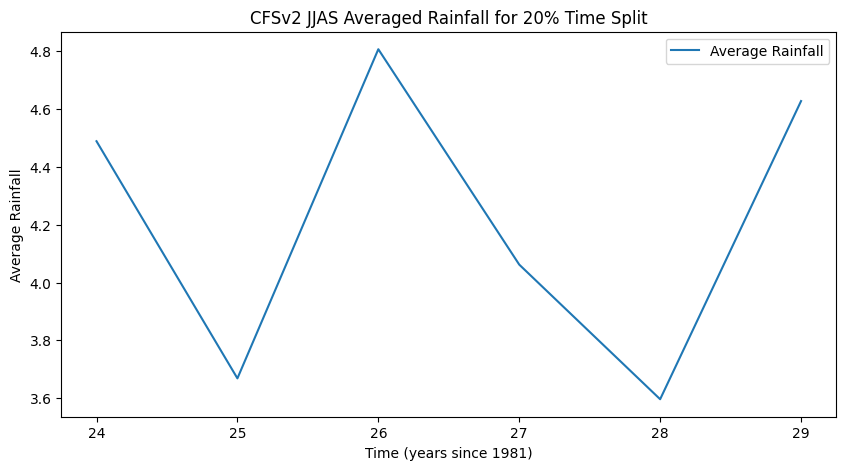

In [4]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Load the NetCDF file
file_path = "/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc"
dataset = nc.Dataset(file_path, 'r')

# Extract the variables
time = dataset.variables['time'][:]
cfs = dataset.variables['cfs'][:]

# Calculate the split index
split_index = int(len(time) * 0.8)

# Split the data
test_time = time[split_index:]
test_cfs = cfs[split_index:]

# Calculate the mean of all ensemble values
mean_cfs = np.mean(test_cfs, axis=(1, 2, 3))

# Plotting the data for the 20% split
plt.figure(figsize=(10, 5))
plt.plot(test_time, mean_cfs, label='Average Rainfall')

plt.xlabel('Time (years since 1981)')
plt.ylabel('Average Rainfall')
plt.title('CFSv2 JJAS Averaged Rainfall for 20% Time Split')
plt.legend()
plt.show()


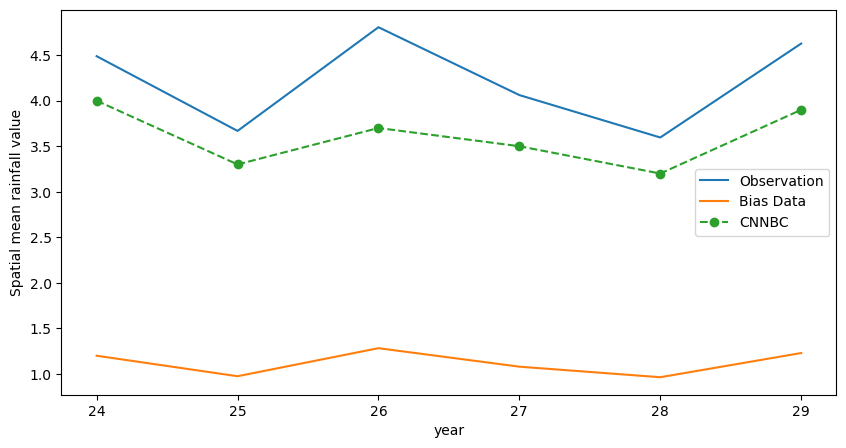

In [6]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Load the NetCDF file
file_path = "/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc"
dataset = nc.Dataset(file_path, 'r')

# Extract the variables
time = dataset.variables['time'][:]
cfs = dataset.variables['cfs'][:]

# Calculate the split index
split_index = int(len(time) * 0.8)

# Split the data
test_time = time[split_index:]
test_cfs = cfs[split_index:]

# Calculate the mean of all ensemble values
overall_mean_cfs = np.mean(test_cfs, axis=(1, 2, 3))

# Number of ensembles and samples
num_ensembles = test_cfs.shape[1]
num_samples_per_year = num_ensembles - 9  # Number of overlapping samples

# Prepare samples and calculate the mean for each year in the test set
mean_cfs_per_year = []

for t in range(test_cfs.shape[0]):
    samples = [np.mean(test_cfs[t, i:i+10, :, :], axis=0) for i in range(num_samples_per_year)]
    mean_cfs = np.mean(samples, axis=(0, 1, 2))  # Mean over latitude, longitude, and samples
    mean_cfs_per_year.append(mean_cfs)

# Convert to numpy array for plotting
mean_cfs_per_year = np.array(mean_cfs_per_year)

additional_time_points = np.linspace(test_time[0], test_time[-1])

# Plotting the data for the last 20% of the time period
plt.figure(figsize=(10, 5))

# Plot overall mean
plt.plot(test_time, overall_mean_cfs, label='Observation')

# Plot mean of overlapping samples
plt.plot(test_time, mean_cfs_per_year, label='Bias Data')

# Plot additional values
plt.plot(additional_time_points, label='CNNBC', linestyle='--', marker='o')

plt.xlabel('year')
plt.ylabel('Spatial mean rainfall value')

plt.legend()
plt.show()
